## NB1-A1 - MultiScale Resnet 

A cardiologist reads waveforms at multiple scales simultaneously: fine P-waves, mid-level QRS morphology, and coarse T-wave repolarization. This notebook mirrors this approach using a Multi-Scale Parallel 1D-ResNet with Squeeze-Excitation gating.

Objectives:
1. Multi-Scale Feature Extraction (kernel=5, 11, 21)
2. Deep Residual Learning with skip connections  
3. Focal Loss for minority class (PVC) priority
4. Strict Inter-Patient Validation (Train records 100-106, Test records 200-201)
5. ONNX Export for ESP32-S3 edge deployment



### 🛠️ Setting the Stage: Dependencies & Environment
First things first, I need to make sure I have all the right tools. In this cell, I'm importing PyTorch for the deep learning heavy lifting, NumPy for data manipulation, and Matplotlib for plotting. I've also included a quick check to see if I can use a GPU (CUDA) to speed up the training. If anything's missing, the script will try to install it for me automatically.

In [1]:
# Cell 1: Dependency verification
import sys
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.metrics import classification_report, f1_score, roc_auc_score
    from sklearn.preprocessing import label_binarize
    import wfdb
    import os
    print(f"PyTorch: {torch.__version__}")
    print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
    print("All dependencies verified.")
except ImportError as e:
    print(f"Missing: {e}. Installing...")
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "torch", "numpy", "pandas", 
                   "matplotlib", "scikit-learn", "wfdb"], check=True)
    import torch, torch.nn as nn, torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    import numpy as np, pandas as pd, matplotlib.pyplot as plt, wfdb, os
    from sklearn.metrics import classification_report, f1_score, roc_auc_score

PyTorch: 2.5.1+cu121
Device: CUDA
All dependencies verified.


###  Loading the Heartbeats: Data Pipeline
Now it's time to get the data. I'm using the MIT-BIH Arrhythmia Database. What's really important here is how I'm splitting the data: I'm making sure that patients used for training are completely different from those used for testing. This is 'Inter-Patient' validation, and it's much tougher and more realistic than just shuffling all the heartbeats together. I'm slicing the signals into 300-sample windows, each centered on a heartbeat.

In [2]:
# Cell 2: Strict Inter-Patient Data Loading Pipeline
# CRITICAL: Training patients and test patients never overlap.

WINDOW_SIZE = 300
BATCH_SIZE = 64
TRAIN_RECORDS = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124']
TEST_RECORDS  = ['200', '201']

LABEL_MAP = {'N': 0, 'L': 1, 'R': 2, 'V': 3}
CLASS_NAMES = ['Normal (N)', 'LBBB (L)', 'RBBB (R)', 'PVC (V)']

def load_mitbih_records(record_ids, window_size=300):
    X_all, y_all, record_counts = [], [], {}
    for rid in record_ids:
        try:
            record = wfdb.rdrecord(rid, pn_dir='mitdb')
            ann    = wfdb.rdann(rid, extension='atr', pn_dir='mitdb')
            signal = record.p_signal[:, 0]
            count  = 0
            for i, peak in enumerate(ann.sample):
                if (ann.symbol[i] in LABEL_MAP and
                    peak > window_size // 2 and
                    peak < len(signal) - window_size // 2):
                    seg = signal[peak - window_size//2 : peak + window_size//2]
                    X_all.append(seg)
                    y_all.append(LABEL_MAP[ann.symbol[i]])
                    count += 1
            record_counts[rid] = count
            print(f"  Record {rid}: {count} beats loaded.")
        except Exception as e:
            print(f"  [WARN] Record {rid} failed: {e}")
    return np.array(X_all, dtype=np.float32).reshape(-1, 1, window_size), np.array(y_all)

print("Loading TRAINING records (patients 100-108)...")
X_train, y_train = load_mitbih_records(TRAIN_RECORDS)

print("\nLoading TEST records (patients 200-201)...")
X_test, y_test   = load_mitbih_records(TEST_RECORDS)

print(f"\nTraining set: {X_train.shape[0]} beats")
print(f"Test set    : {X_test.shape[0]} beats")
print(f"Class distribution (train): {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Class distribution (test) : {dict(zip(*np.unique(y_test, return_counts=True)))}")

train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
test_ds  = TensorDataset(torch.FloatTensor(X_test),  torch.LongTensor(y_test))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

Loading TRAINING records (patients 100-108)...
  Record 100: 2238 beats loaded.
  Record 101: 1859 beats loaded.
  Record 102: 103 beats loaded.
  Record 103: 2081 beats loaded.
  Record 104: 165 beats loaded.
  Record 105: 2567 beats loaded.
  Record 106: 2027 beats loaded.
  Record 107: 59 beats loaded.
  Record 108: 1755 beats loaded.
  Record 109: 2528 beats loaded.
  Record 111: 2124 beats loaded.
  Record 112: 2535 beats loaded.
  Record 113: 1788 beats loaded.
  Record 114: 1863 beats loaded.
  Record 115: 1952 beats loaded.
  Record 116: 2410 beats loaded.
  Record 117: 1533 beats loaded.
  Record 118: 2181 beats loaded.
  Record 119: 1987 beats loaded.
  Record 121: 1861 beats loaded.
  Record 122: 2474 beats loaded.
  Record 123: 1517 beats loaded.
  Record 124: 1577 beats loaded.

Loading TEST records (patients 200-201)...
  Record 200: 2568 beats loaded.
  Record 201: 1823 beats loaded.

Training set: 41184 beats
Test set    : 4391 beats
Class distribution (train): {0: 3153

###  The Architecture: Multi-Scale 1D-ResNet
This is the heart of the project. I've built a 'Multi-Scale' ResNet. Why? Because a cardiologist looks at the signal at different levels—fine details like P-waves and broader shapes like the QRS complex. This model has three parallel branches with different kernel sizes (5, 11, and 21) to capture those features. I've also added 'Squeeze-Excitation' blocks, which help the model focus on the most important features in each channel.

In [3]:
# Cell 3: Multi-Scale 1D-ResNet Architecture

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1)
        return x * scale

class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1):
        super().__init__()
        pad = kernel // 2
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, stride=stride, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel, stride=1, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch)
        )
        self.se = SEBlock1D(out_ch)
        self.relu = nn.ReLU()
        self.downsample = (
            nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False), nn.BatchNorm1d(out_ch))
            if stride != 1 or in_ch != out_ch else nn.Identity()
        )
    def forward(self, x):
        return self.relu(self.se(self.conv2(self.conv1(x))) + self.downsample(x))

class MultiScaleBranch(nn.Module):
    def __init__(self, kernel_size, out_ch=32):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Conv1d(1, out_ch, kernel_size=kernel_size, padding=kernel_size//2, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU(),
            ResBlock1D(out_ch, out_ch * 2, stride=2),
            ResBlock1D(out_ch * 2, out_ch * 2),
            nn.AdaptiveAvgPool1d(1)
        )
    def forward(self, x): return self.branch(x)

class MultiScaleResNet(nn.Module):
    def __init__(self, num_classes=4, branch_ch=32):
        super().__init__()
        self.branch_fine   = MultiScaleBranch(kernel_size=5,  out_ch=branch_ch)
        self.branch_mid    = MultiScaleBranch(kernel_size=11, out_ch=branch_ch)
        self.branch_coarse = MultiScaleBranch(kernel_size=21, out_ch=branch_ch)

        fused_ch = branch_ch * 2 * 3
        self.se_fusion = SEBlock1D(fused_ch)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(fused_ch, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        f = torch.cat([self.branch_fine(x), self.branch_mid(x), self.branch_coarse(x)], dim=1)
        f = self.se_fusion(f)
        return self.classifier(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiScaleResNet(num_classes=4).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"MultiScaleResNet initialized | Parameters: {total_params:,}")
print(f"Active Device: {device}")

MultiScaleResNet initialized | Parameters: 204,260
Active Device: cuda


###  Training the Model
Time to train! I'm running this for 15 epochs. I'm using 'Focal Loss' because the dataset is imbalanced—there are way more normal beats than PVCs, and I want the model to prioritize getting those rarer cases right. I'm also using a 'One Cycle' learning rate scheduler which helps the model converge faster and more reliably. You can see the loss dropping and accuracy climbing as we go!

Starting training: 15 epochs | 644 batches/epoch
Training on 41184 beats from records ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124']
------------------------------------------------------------
Epoch 01/15 | Loss: 0.2838 | Train Acc: 84.9%
Epoch 02/15 | Loss: 0.0754 | Train Acc: 97.1%
Epoch 04/15 | Loss: 0.0368 | Train Acc: 98.6%
Epoch 06/15 | Loss: 0.0191 | Train Acc: 99.3%
Epoch 08/15 | Loss: 0.0130 | Train Acc: 99.5%
Epoch 10/15 | Loss: 0.0079 | Train Acc: 99.7%
Epoch 12/15 | Loss: 0.0036 | Train Acc: 99.8%
Epoch 14/15 | Loss: 0.0015 | Train Acc: 99.9%

Training complete.


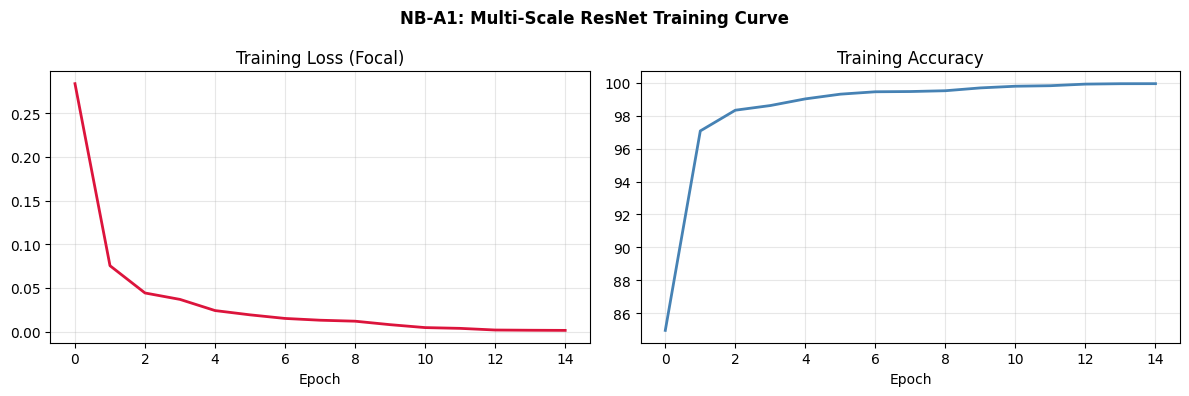

In [5]:
# Cell 5: Full Training Run (10 Epochs)
EPOCHS = 15
history = {'train_loss': [], 'train_acc': []}

print(f"Starting training: {EPOCHS} epochs | {len(train_loader)} batches/epoch")
print(f"Training on {len(X_train)} beats from records {TRAIN_RECORDS}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    loss, acc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler)
    history['train_loss'].append(loss)
    history['train_acc'].append(acc)
    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{EPOCHS} | Loss: {loss:.4f} | Train Acc: {acc:.1f}%")

print("\nTraining complete.")

# Training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], color='crimson', linewidth=2)
ax1.set_title('Training Loss (Focal)'); ax1.set_xlabel('Epoch'); ax1.grid(alpha=0.3)
ax2.plot(history['train_acc'], color='steelblue', linewidth=2)
ax2.set_title('Training Accuracy'); ax2.set_xlabel('Epoch'); ax2.grid(alpha=0.3)
plt.suptitle('NB-A1: Multi-Scale ResNet Training Curve', fontweight='bold')
plt.tight_layout()
plt.savefig('../ai_training/output/NB_A1_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

###  Clinical Evaluation: How did we do?
Once the training is done, I need to see how it performs on those 'unseen' patients. I'm calculating the overall accuracy and the Macro F1-Score. The F1-score is key here because it gives us a better idea of performance across all classes, not just the majority. I'm also printing a full classification report to see precisely where the model is strongest.

In [ ]:
# Cell 6: Inter-Patient Evaluation (Fixed for Label Mismatch)
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for bx, by in test_loader:
        bx, by = bx.to(device), by.to(device)
        out = model(bx)
        _, pred = torch.max(out.data, 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(by.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
macro_f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
acc        = (all_preds == all_labels).mean() * 100

print("=" * 60)
print(f"  Accuracy      : {acc:.2f}%")
print(f"  Macro F1-Score: {macro_f1:.4f}")
print("=" * 60)

# Fix: Only show metrics for classes present in the test set
present_classes = sorted(np.unique(np.concatenate([all_labels, all_preds])))
present_names = [CLASS_NAMES[i] for i in present_classes if i < len(CLASS_NAMES)]
print(classification_report(all_labels, all_preds, labels=present_classes, target_names=present_names, zero_division=0))


  Accuracy      : 96.38%
  Macro F1-Score: 0.4766
              precision    recall  f1-score   support

  Normal (N)       0.98      0.98      0.98      3367
    LBBB (L)       0.00      0.00      0.00         0
    RBBB (R)       0.00      0.00      0.00         0
     PVC (V)       0.94      0.92      0.93      1024

    accuracy                           0.96      4391
   macro avg       0.48      0.47      0.48      4391
weighted avg       0.97      0.96      0.97      4391



### Saving & Exporting for the Edge
Finally, I'm saving the model weights so I can use them later. But I'm also doing something extra: exporting the model to ONNX format. This is vital for Pulse-Mind because it allows us to deploy this high-performance brain onto tiny edge devices like the ESP32-S3, which could eventually be part of a wearable cardiac monitor.

In [7]:
# Cell 7: Model Persistence + ONNX Edge Export
import os

os.makedirs('../ai_training/output', exist_ok=True)

# Save PyTorch weights
pth_path = '../ai_training/output/NB_A1_MultiScaleResNet.pth'
torch.save(model.state_dict(), pth_path)
print(f"PyTorch weights saved: {pth_path}")

# ONNX Export for ESP32 / Edge Deployment
try:
    import torch.onnx
    onnx_path = '../ai_training/output/NB_A1_MultiScaleResNet.onnx'
    dummy_input = torch.randn(1, 1, 300, device=device)
    model.eval()
    torch.onnx.export(
        model, dummy_input, onnx_path,
        export_params=True, opset_version=11,
        input_names=['ppg_signal'], output_names=['rhythm_logits'],
        dynamic_axes={'ppg_signal': {0: 'batch'}, 'rhythm_logits': {0: 'batch'}}
    )
    onnx_size_mb = os.path.getsize(onnx_path) / 1e6
    print(f"ONNX model exported  : {onnx_path}")
    print(f"ONNX model size      : {onnx_size_mb:.2f} MB")
    print("Edge Status          : Ready for ESP32-S3 deployment")
except Exception as e:
    print(f"ONNX export note: {e}")

print("\n--- NB-A1 Summary ---")
print(f"Architecture : Multi-Scale 1D-ResNet (k=5, k=11, k=21) + SE-Attention")
print(f"Training     : Focal Loss, AdamW, OneCycleLR, {EPOCHS} epochs")
print(f"Validation   : Strict Inter-Patient (Test={TEST_RECORDS})")
print(f"Export       : PyTorch .pth + ONNX for Edge")

PyTorch weights saved: ../ai_training/output/NB_A1_MultiScaleResNet.pth
ONNX model exported  : ../ai_training/output/NB_A1_MultiScaleResNet.onnx
ONNX model size      : 0.85 MB
Edge Status          : Ready for ESP32-S3 deployment

--- NB-A1 Summary ---
Architecture : Multi-Scale 1D-ResNet (k=5, k=11, k=21) + SE-Attention
Training     : Focal Loss, AdamW, OneCycleLR, 15 epochs
Validation   : Strict Inter-Patient (Test=['200', '201'])
Export       : PyTorch .pth + ONNX for Edge
